# Driver Monitoring System — Seatbelt Detection Module

This notebook trains the seatbelt detection module of the DMS graduation project. The idea is the same as the smoking detection module: a YOLO object detector is trained to recognize a specific driver behavior (in this case, whether the seatbelt is worn or not) so it can be combined with the other modules into a complete monitoring system.

Unlike the smoking module, the dataset here comes directly from Roboflow, and the detector is based on YOLOv12 instead of YOLO11. Steps covered below:

1. Installing dependencies
2. Downloading the dataset from Roboflow
3. Checking a sample of annotated images
4. Training YOLOv12n on the dataset
5. Inspecting training curves
6. Evaluating on the validation split
7. Visualizing predictions on validation images
8. Testing on a custom uploaded image

## 1. Dependencies

Two packages are needed here: `roboflow`, to pull the dataset directly from the Roboflow project instead of manually uploading a zip file, and `ultralytics`, for the YOLOv12 training/inference API.

In [1]:
# Install dependencies
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.0 MB/s eta 0:00:00


## 2. Dataset Download

The seatbelt dataset is hosted on Roboflow under the `seatbelt-cuunt` project. Downloading it in `yolov8` format works fine here since Ultralytics uses the same annotation format for YOLOv8 through YOLOv12 — only the model architecture changes, not the label format. The path to the generated `data.yaml` is stored for use in the following cells.

In [2]:
# Download dataset
from roboflow import Roboflow

rf = Roboflow(api_key="xcDJdDJpIdytumuUX8pM")
project = rf.workspace("patok-tok-patok").project("seatbelt-cuunt")
version = project.version(2)
dataset = version.download("yolov8")  # ultralytics uses yolov8 format

import os
DATA_YAML = os.path.join(dataset.location, "data.yaml")
print("data.yaml:", DATA_YAML)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Seatbelt-2 in yolov8:: 100%|██████████| 9401/9401 [00:01<00:00, 6606.78it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
data.yaml: /content/Seatbelt-2/data.yaml


## 3. Annotation Check

Before training, a batch of 9 random training images is drawn and the bounding boxes are drawn on top using OpenCV, one color per class. This is just to confirm the download went through correctly and that the boxes line up with the seatbelt/no-seatbelt regions as expected, rather than trusting the dataset blindly.

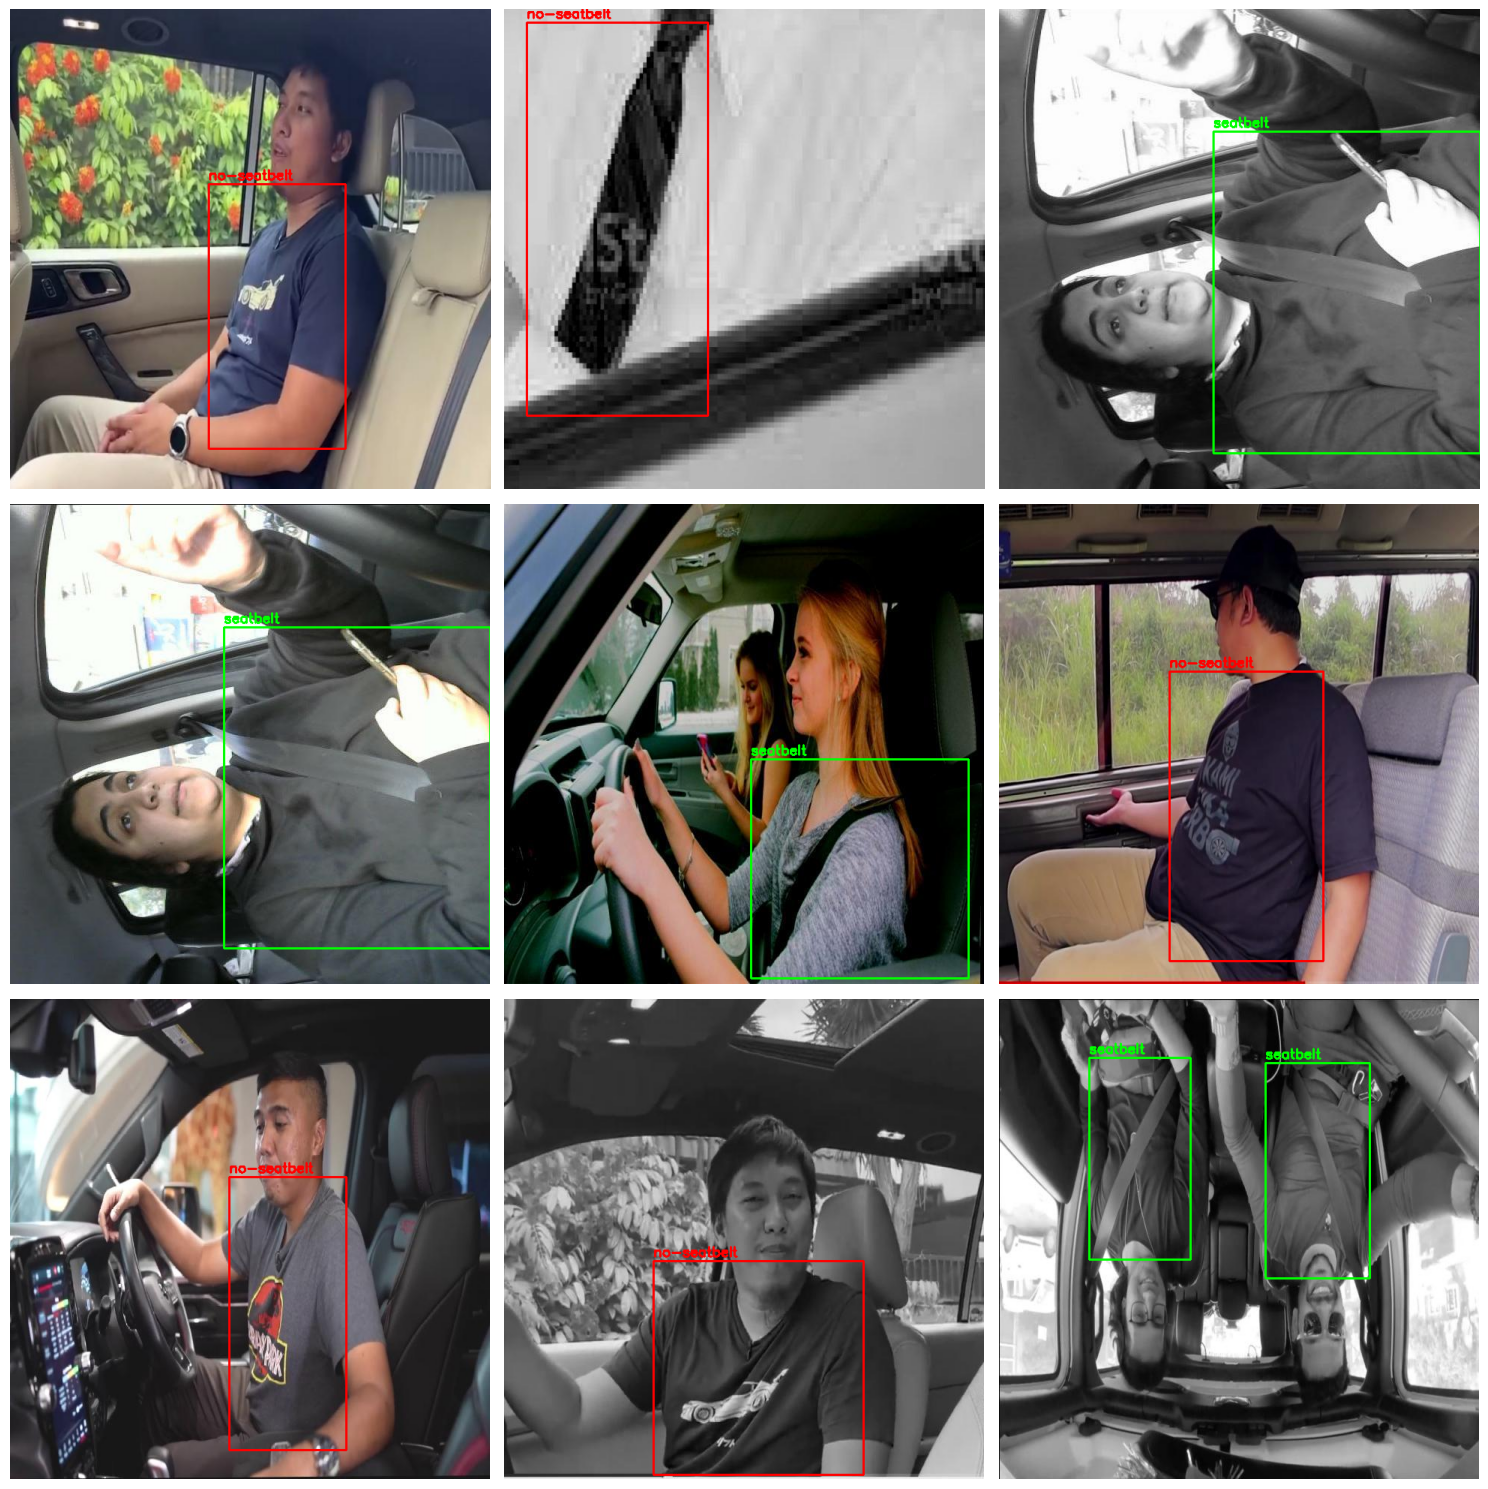

Classes: ['no-seatbelt', 'seatbelt']


In [3]:
# Preview a sample of training images with bounding boxes
import os, random, cv2, yaml
from matplotlib import pyplot as plt

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
class_names = cfg["names"]

train_img_dir = os.path.join(dataset.location, "train", "images")
train_lbl_dir = os.path.join(dataset.location, "train", "labels")

samples = random.sample(os.listdir(train_img_dir), 9)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
COLORS = [(255,0,0),(0,255,0),(0,0,255),(255,165,0),(128,0,128)]

for ax, fname in zip(axes.flat, samples):
    img = cv2.cvtColor(cv2.imread(os.path.join(train_img_dir, fname)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = os.path.join(train_lbl_dir, fname.rsplit(".", 1)[0] + ".txt")
    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            cls, xc, yc, bw, bh = map(float, line.split())
            cls = int(cls)
            x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
            color = COLORS[cls % len(COLORS)]
            cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
            cv2.putText(img, class_names[cls], (x1, y1-6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    ax.imshow(img); ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Classes: {class_names}")

## 4. Model Training

Training uses `yolo12n.pt`, the nano variant of YOLOv12, as a starting point — a good tradeoff between speed and accuracy for this stage of the project, since it trains faster and is easier to iterate on than the larger variants (s/m/l), which can be swapped in later if more accuracy is needed. Training runs for 50 epochs at 640x640 resolution with a batch size of 16, and `patience=10` stops training early if validation performance plateaus so time isn't wasted on epochs that aren't improving the model. `device=0` runs everything on the first available GPU.

In [5]:
# Train YOLOv12
from ultralytics import YOLO

model = YOLO("yolo12n.pt")  # nano — change to yolo12s/m/l for larger models

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    name="seatbelt_yolo12",
    project="runs/train",
    patience=10,
    device=0,
)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Seatbelt-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seatbelt_yolo12-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

## 5. Training Curves

Ultralytics automatically saves a `results.png` summarizing loss and metric curves across all epochs. Displaying it here gives a quick visual read on whether the model was still improving, overfitting, or had already converged by the end of training.

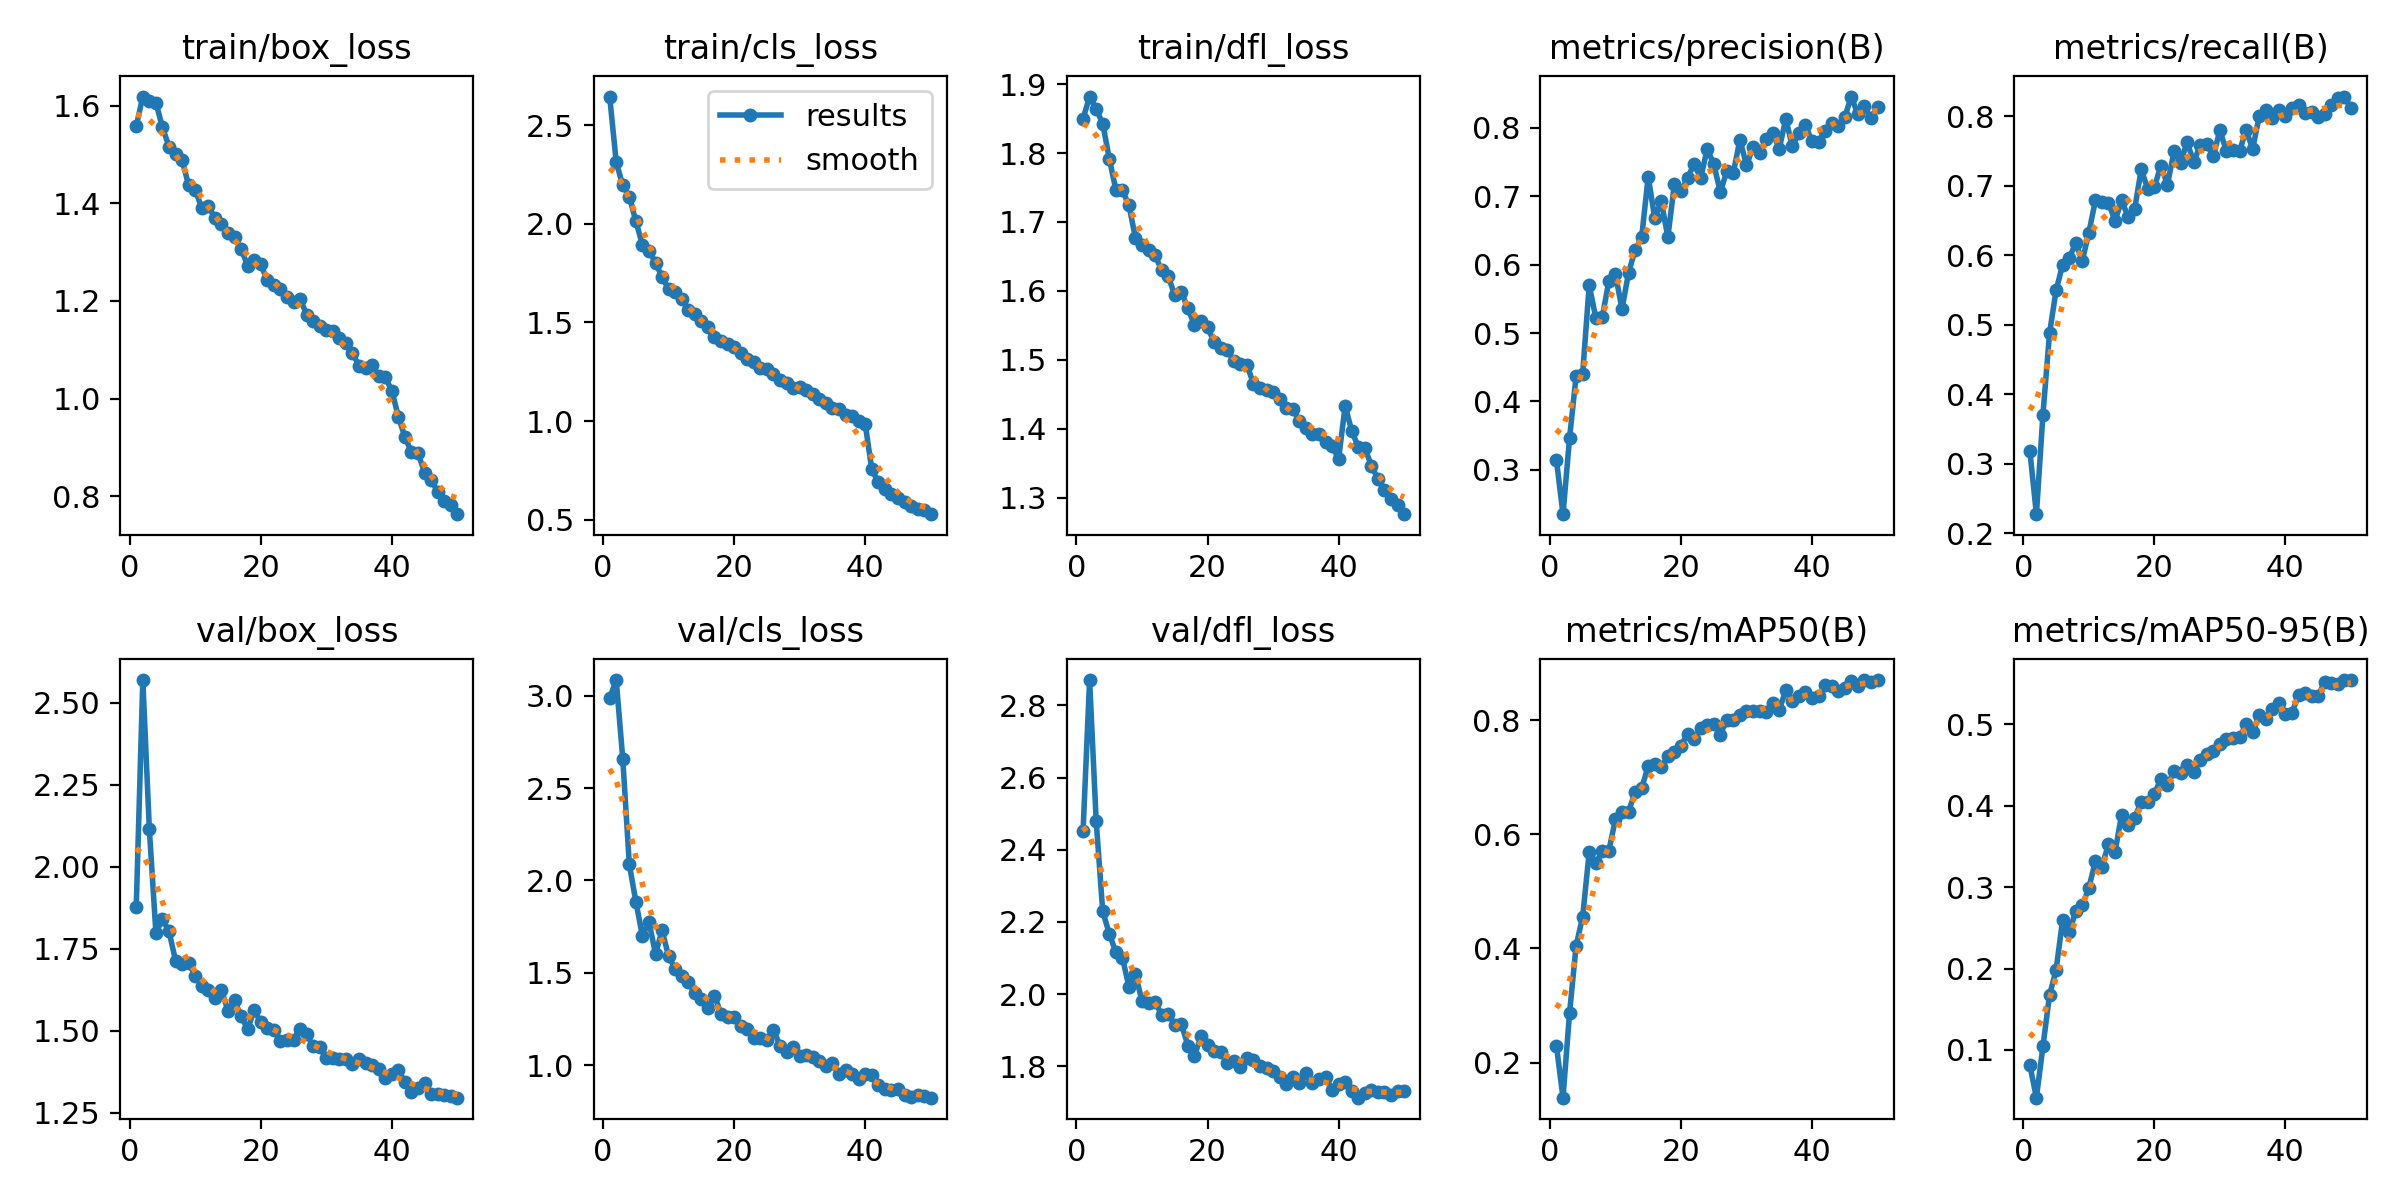

In [7]:
# Show training curves
from IPython.display import Image as IPImage
IPImage("/content/runs/detect/runs/train/seatbelt_yolo12-2/results.png", width=900)

## 6. Evaluation

The best checkpoint from training is reloaded and validated on the validation split to get the standard detection metrics (precision, recall, mAP@0.5, mAP@0.5:0.95). These numbers are the main quantitative result for this module and will feed into the overall performance summary of the DMS project.

In [12]:
# Evaluate on test set
best_weights = "/content/runs/detect/runs/train/seatbelt_yolo12-2/weights/best.pt"
model_best = YOLO(best_weights)

metrics = model_best.val(
    data=DATA_YAML,
    split="val",
    imgsz=640,
    device=0,
)
print(metrics)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1854.1±739.8 MB/s, size: 48.2 KB)
val: Scanning /content/Seatbelt-2/valid/labels.cache... 828 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 828/828 315.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 5.0it/s 10.3s
                   all        828        936      0.832      0.811       0.87      0.556
           no-seatbelt        427        449      0.768      0.751      0.808      0.495
              seatbelt        419        487      0.897      0.872      0.933      0.616
Speed: 1.4ms preprocess, 6.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val-3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])


## 7. Predictions on Validation Images

To get a qualitative sense of how the model performs beyond the raw metrics, six random images from the validation set are run through the model and the predicted boxes are plotted in a grid. This makes it easier to spot obvious failure cases (e.g. missed detections or false positives) that a single mAP number wouldn't show on its own.

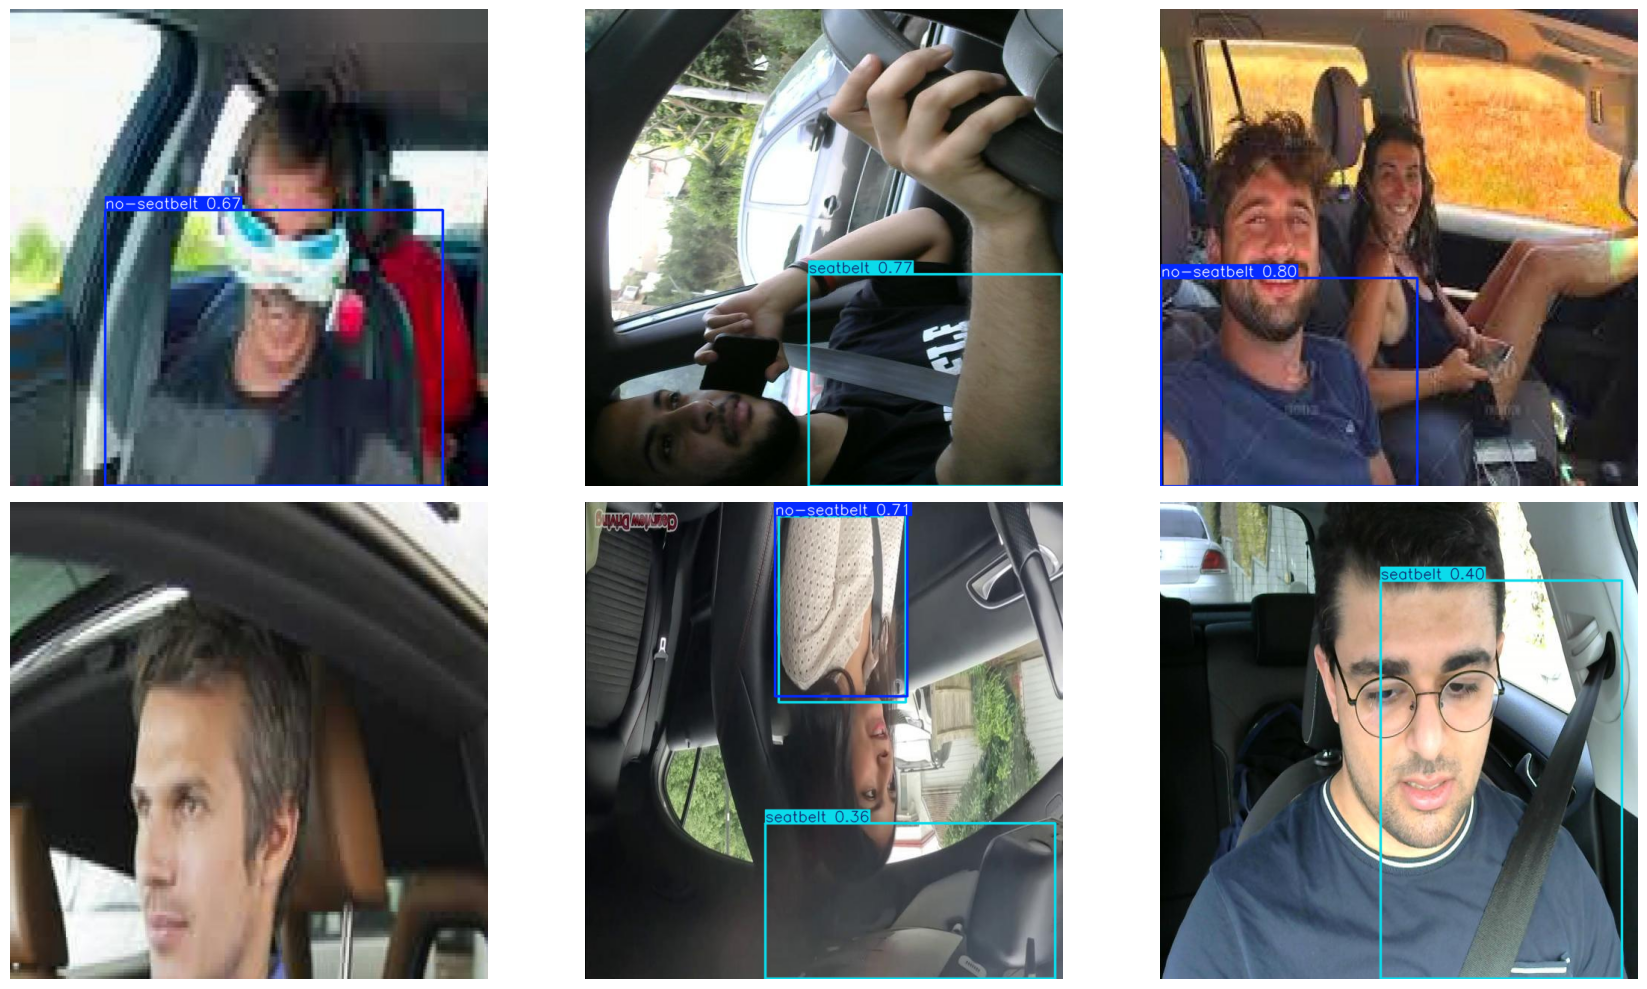

In [13]:
import random, cv2
from matplotlib import pyplot as plt

val_imgs = glob.glob(os.path.join(dataset.location, "valid", "images", "*"))
samples = random.sample(val_imgs, min(6, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, path in zip(axes.flat, samples):
    res = model_best(path, conf=0.3, verbose=False)[0]
    img = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.axis("off")
plt.tight_layout(); plt.show()

## 8. Test on a Custom Image

As a final sanity check, this cell lets you upload an image directly (outside the training/validation set) and run the trained model on it. The detections are drawn on the image and each predicted class with its confidence score is printed below, which is closer to how the model would actually be used once integrated into the full DMS pipeline.

Saving images.jpg to images.jpg


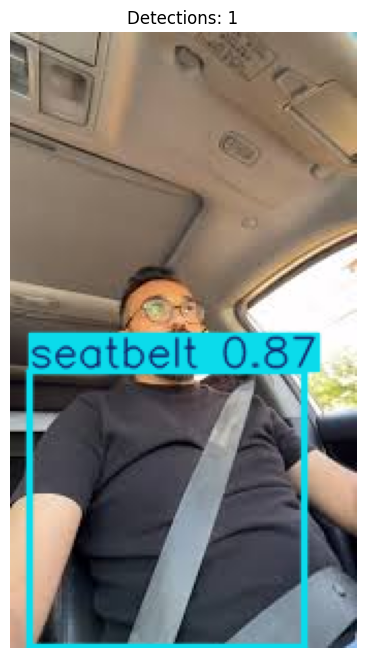

  seatbelt  conf=0.87


In [15]:
# Test on custom external image
from google.colab import files
import cv2
from matplotlib import pyplot as plt

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

res = model_best(img_path, conf=0.3, verbose=False)[0]
out = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(out); plt.axis("off")
plt.title(f"Detections: {len(res.boxes)}")
plt.show()

for box in res.boxes:
    cls_id = int(box.cls)
    print(f"  {class_names[cls_id]}  conf={float(box.conf):.2f}")

## Summary and Conclusion

This notebook trained a YOLOv12n detector for seatbelt usage using a Roboflow-hosted dataset. After downloading and visually verifying the annotations, the model was trained for 50 epochs and evaluated on the validation split, then tested qualitatively on both validation samples and a custom uploaded image.

Combined with the smoking detection module trained separately, this gives two of the core behavior-detection components of the Driver Monitoring System. Next steps for this module would be trying a larger YOLOv12 variant (s/m) if accuracy needs to improve, and collecting more varied seatbelt images (different angles, lighting, clothing) to make the model more robust before integrating it into the final system.